# Parameter Optimization — Gradient, GA & CMA-ES

SeapoPym supports three families of optimizers. This notebook compares them on the
same **twin experiment** (0D LMTL model, 3 parameters, clean & noisy observations).

| Optimizer           | Type              | Gradients      | Library |
| ------------------- | ----------------- | -------------- | ------- |
| `GradientOptimizer` | Adam              | Yes (autodiff) | Optax   |
| `GAOptimizer`       | Genetic Algorithm | No             | evosax  |
| `CMAESOptimizer`    | CMA-ES            | No             | evosax  |

**What you will learn:**

1. How to set up a **twin experiment**.
2. How each optimizer is configured and run.
3. How they compare in **convergence speed** and **parameter recovery**.
4. How **observation noise** affects each method differently.


In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import seapopym.functions.lmtl  # noqa: F401 — register LMTL physics functions
from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import build_step_fn, run
from seapopym.models import LMTL_NO_TRANSPORT
from seapopym.optimization import (
    CMAESOptimizer,
    GAOptimizer,
    GradientOptimizer,
    Objective,
)
from seapopym.optimization.prior import PriorSet

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.0.1
JAX devices: [CpuDevice(id=0)]


## 1. Twin Experiment Setup

A **twin experiment** validates an optimizer by running the model with known
parameters, extracting synthetic observations, then optimizing from **wrong initial
guesses** to recover the truth.

We optimize **3 parameters** (the others stay fixed at their true values):

| Parameter      | Description                            | True Value | Initial Guess (50%) |
| -------------- | -------------------------------------- | ---------- | ------------------- |
| `efficiency`   | NPP transfer efficiency                | 0.1668     | 0.0834              |
| `gamma_lambda` | Thermal sensitivity of mortality       | 0.15 /°C   | 0.075               |
| `gamma_tau_r`  | Thermal sensitivity of recruitment age | 0.11 /°C   | 0.055               |


In [2]:
# --- True parameter values ---
TRUE_PARAMS = {
    "lambda_0": 1 / 150 / 86400,
    "gamma_lambda": 0.15,
    "tau_r_0": 10.38 * 86400,
    "gamma_tau_r": 0.11,
    "efficiency": 0.1668,
    "t_ref": 0.0,
}

# Parameters to optimize
OPT_PARAM_NAMES = ["efficiency", "gamma_lambda", "gamma_tau_r"]
BOUNDS = {
    "efficiency": (0.01, 5 * TRUE_PARAMS["efficiency"]),
    "gamma_lambda": (0.01, 5 * TRUE_PARAMS["gamma_lambda"]),
    "gamma_tau_r": (0.01, 5 * TRUE_PARAMS["gamma_tau_r"]),
}

# Initial guesses: 50% of true values
INIT_PARAMS = {k: 0.5 * TRUE_PARAMS[k] for k in OPT_PARAM_NAMES}

# Time setup
SPINUP_YEARS = 1
OPT_YEARS = 2
DT = "1d"
OBS_FRACTION = 0.10
SEED = 42
NOISE_LEVELS = [0.0, 0.15]

print("Twin experiment:")
for p in OPT_PARAM_NAMES:
    print(
        f"  {p:<14} true={TRUE_PARAMS[p]:.4g}  init={INIT_PARAMS[p]:.4g}  "
        f"bounds=({BOUNDS[p][0]:.4g}, {BOUNDS[p][1]:.4g})"
    )

Twin experiment:
  efficiency     true=0.1668  init=0.0834  bounds=(0.01, 0.834)
  gamma_lambda   true=0.15  init=0.075  bounds=(0.01, 0.75)
  gamma_tau_r    true=0.11  init=0.055  bounds=(0.01, 0.55)


## 2. Model & Observations

We use the `LMTL_NO_TRANSPORT` blueprint on a 1×1 grid with seasonal forcings.
The model is compiled with **perturbed parameters** (50% of true). Observations are
generated by running with the true values, then sampling 10% of timesteps.


In [3]:
blueprint = LMTL_NO_TRANSPORT

# --- Time ---
total_years = SPINUP_YEARS + OPT_YEARS
start_date = "2000-01-01"
end_date = str((pd.Timestamp(start_date) + pd.DateOffset(years=total_years)).date())
dates = pd.date_range(
    start=pd.to_datetime(start_date),
    periods=(pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 5,
    freq="D",
)
doy = dates.dayofyear.values.astype(float)

# --- Grid (1×1) ---
ny, nx = 1, 1
lat, lon = np.arange(ny), np.arange(nx)

# --- Cohorts ---
max_age_days = int(np.ceil(TRUE_PARAMS["tau_r_0"] * 5 / 86400))
cohort_ages_sec = np.arange(0, max_age_days + 1) * 86400.0
n_cohorts = len(cohort_ages_sec)

# --- Forcings ---
temp_c = 15.0 + 5.0 * np.sin(2 * np.pi * doy / 365.0)
temp_4d = np.broadcast_to(temp_c[:, None, None, None], (len(dates), 1, ny, nx))
npp_sec = (1.0 + 0.5 * np.sin(2 * np.pi * doy / 365.0)) / 86400.0
npp_3d = np.broadcast_to(npp_sec[:, None, None], (len(dates), ny, nx))

# --- Config with PERTURBED initial guesses ---
config = Config(
    parameters={
        "lambda_0": xr.DataArray([TRUE_PARAMS["lambda_0"]], dims=["F"]),
        "gamma_lambda": xr.DataArray([INIT_PARAMS["gamma_lambda"]], dims=["F"]),
        "tau_r_0": xr.DataArray([TRUE_PARAMS["tau_r_0"]], dims=["F"]),
        "gamma_tau_r": xr.DataArray([INIT_PARAMS["gamma_tau_r"]], dims=["F"]),
        "t_ref": xr.DataArray(TRUE_PARAMS["t_ref"]),
        "efficiency": xr.DataArray([INIT_PARAMS["efficiency"]], dims=["F"]),
        "cohort_ages": xr.DataArray(cohort_ages_sec, dims=["C"]),
        "day_layer": xr.DataArray([0], dims=["F"]),
        "night_layer": xr.DataArray([0], dims=["F"]),
    },
    forcings={
        "latitude": xr.DataArray(np.full(ny, 30.0), dims=["Y"], coords={"Y": lat}),
        "temperature": xr.DataArray(
            temp_4d,
            dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(1), "Y": lat, "X": lon},
        ),
        "primary_production": xr.DataArray(
            npp_3d,
            dims=["T", "Y", "X"],
            coords={"T": dates, "Y": lat, "X": lon},
        ),
        "day_of_year": xr.DataArray(doy, dims=["T"], coords={"T": dates}),
    },
    initial_state={
        "biomass": xr.DataArray(np.zeros((1, ny, nx)), dims=["F", "Y", "X"], coords={"Y": lat, "X": lon}),
        "production": xr.DataArray(
            np.zeros((1, n_cohorts, ny, nx)),
            dims=["F", "C", "Y", "X"],
            coords={"Y": lat, "X": lon},
        ),
    },
    execution={
        "time_start": start_date,
        "time_end": end_date,
        "dt": DT,
        "forcing_interpolation": "linear",
    },
)

model = compile_model(blueprint, config)
step_fn = build_step_fn(model, export_variables=["biomass"])
n_timesteps = model.n_timesteps
spinup_steps = int(SPINUP_YEARS / total_years * n_timesteps)
dt_sec = model.dt

print(f"Model: {n_timesteps} timesteps ({spinup_steps} spin-up, dt={dt_sec:.0f}s)")

Model: 1096 timesteps (365 spin-up, dt=86400s)


### Process DAG

Visualize the computation graph of the blueprint:


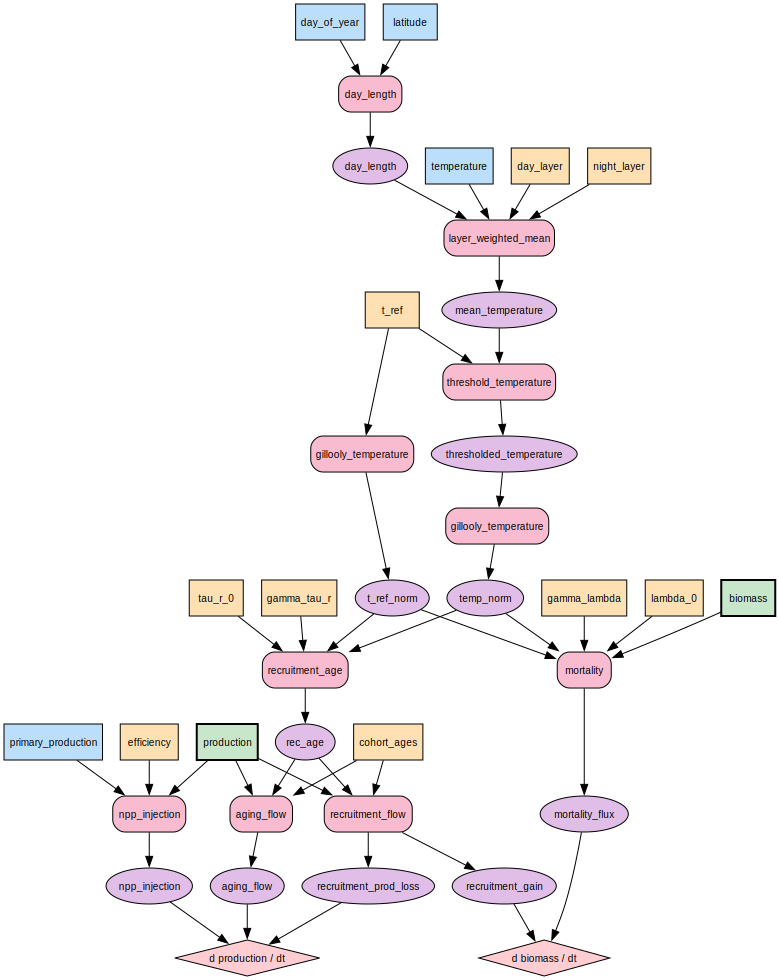

In [4]:
blueprint.to_graphviz()

In [5]:
# --- Generate observations with TRUE parameters ---
true_params_jax = {k: jnp.array([TRUE_PARAMS[k]]) for k in OPT_PARAM_NAMES}
_, outputs_true = run(step_fn, model, dict(model.state), {**model.parameters, **true_params_jax})

biomass_true = outputs_true["biomass"]
true_ts_full = jnp.mean(biomass_true, axis=tuple(range(1, biomass_true.ndim)))
true_ts = true_ts_full[spinup_steps:]
n_opt_steps = len(true_ts)

# Sample observation indices
rng = np.random.default_rng(SEED)
n_obs = max(2, int(OBS_FRACTION * n_opt_steps))
obs_local_idx = np.sort(rng.choice(n_opt_steps, size=n_obs, replace=False))
obs_global_idx = obs_local_idx + spinup_steps
obs_clean = np.array(true_ts[obs_local_idx])
time_days = np.arange(n_opt_steps) * dt_sec / 86400.0

print(f"Observations: {n_obs} points ({100 * n_obs / n_opt_steps:.0f}% of timesteps)")
print(f"True biomass range: [{float(true_ts.min()):.6f}, {float(true_ts.max()):.6f}] g/m²")

Observations: 73 points (10% of timesteps)
True biomass range: [2.300462, 3.131231] g/m²


In [6]:
def extract_predictions(outputs):
    """Extract biomass at observation timesteps."""
    biomass = outputs["biomass"]
    ts = jnp.mean(biomass, axis=tuple(range(1, biomass.ndim)))
    return ts[obs_global_idx]

## 3. Run Optimizers

We run all three optimizers on both clean and noisy (15%) observations.

- **Gradient** (Adam): 300 steps, `scaling="bounds"`, differentiates through the
  full simulation via `jax.value_and_grad`.
- **GA** (SimpleGA): 150 generations, population of 64.
- **CMA-ES**: 150 generations, population of 32. Learns the search covariance
  matrix adaptively.


In [7]:
all_results = {}  # {(noise_level, method_name): {"result": ..., "elapsed": ...}}

for noise_level in NOISE_LEVELS:
    noise_label = "clean" if noise_level == 0.0 else f"noise={noise_level:.0%}"

    # Prepare observations
    if noise_level > 0:
        noise_rng = np.random.default_rng(SEED + 1)
        obs_values = jnp.array(obs_clean + noise_rng.normal(0, noise_level * np.abs(obs_clean)))
    else:
        obs_values = jnp.array(obs_clean)

    objective = Objective(observations=obs_values, transform=extract_predictions)

    print(f"\n{'=' * 60}")
    print(f"  {noise_label.upper()}")
    print(f"{'=' * 60}")

    # --- Gradient (Adam) ---
    print("\n  Gradient (Adam, 300 steps)...")
    opt_grad = GradientOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        algorithm="adam",
        learning_rate=0.01,
        scaling="bounds",
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_grad = opt_grad.run(model, n_steps=300, tolerance=1e-8, progress_bar=True)
    t_grad = time.time() - t0
    all_results[(noise_level, "Gradient")] = {"result": res_grad, "elapsed": t_grad}
    print(f"    loss={res_grad.loss:.4e} | {res_grad.n_iterations} iters | {t_grad:.1f}s")

    # --- GA ---
    print("\n  GA (popsize=64, 100 gen)...")
    opt_ga = GAOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        popsize=64,
        seed=SEED,
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_ga = opt_ga.run(model, n_generations=150, patience=50, progress_bar=True)
    t_ga = time.time() - t0
    all_results[(noise_level, "GA")] = {"result": res_ga, "elapsed": t_ga}
    print(f"    loss={res_ga.loss:.4e} | {res_ga.n_iterations} gen | {t_ga:.1f}s")

    # --- CMA-ES ---
    print("\n  CMA-ES (popsize=32, 100 gen)...")
    opt_cmaes = CMAESOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        popsize=32,
        seed=SEED,
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_cmaes = opt_cmaes.run(model, n_generations=150, patience=50, progress_bar=True)
    t_cmaes = time.time() - t0
    all_results[(noise_level, "CMA-ES")] = {"result": res_cmaes, "elapsed": t_cmaes}
    print(f"    loss={res_cmaes.loss:.4e} | {res_cmaes.n_iterations} gen | {t_cmaes:.1f}s")


  CLEAN

  Gradient (Adam, 300 steps)...
  [300/300] loss=1.3679e-04
    loss=1.3183e-04 | 300 iters | 41.8s

  GA (popsize=64, 100 gen)...
  [127/150] loss=4.9072e-04
    loss=4.9072e-04 | 128 gen | 1.3s

  CMA-ES (popsize=32, 100 gen)...
  [64/150] loss=9.1520e-05
    loss=9.1520e-05 | 66 gen | 1.1s

  NOISE=15%

  Gradient (Adam, 300 steps)...
  [300/300] loss=1.6164e-01
    loss=1.6164e-01 | 300 iters | 43.6s

  GA (popsize=64, 100 gen)...
  [85/150] loss=1.6589e-01
    loss=1.6589e-01 | 90 gen | 0.8s

  CMA-ES (popsize=32, 100 gen)...
  [150/150] loss=1.6114e-01
    loss=1.6114e-01 | 150 gen | 0.9s


## 4. Parameter Recovery


In [8]:
METHODS = ["Gradient", "GA", "CMA-ES"]

for noise_level in NOISE_LEVELS:
    noise_label = "Clean" if noise_level == 0.0 else f"Noise {noise_level:.0%}"
    print(f"\n{'=' * 60}")
    print(f"  {noise_label}")
    print(f"{'=' * 60}")
    print(f"  {'Parameter':<14} {'True':>10} {'Gradient':>10} {'GA':>10} {'CMA-ES':>10}")
    print(f"  {'-' * 54}")
    for p in OPT_PARAM_NAMES:
        true_val = TRUE_PARAMS[p]
        vals = []
        for m in METHODS:
            v = float(jnp.squeeze(all_results[(noise_level, m)]["result"].params[p]))
            vals.append(v)
        print(f"  {p:<14} {true_val:>10.4g} {vals[0]:>10.4g} {vals[1]:>10.4g} {vals[2]:>10.4g}")

    print(f"\n  {'Ratio to true':}")
    print(f"  {'-' * 54}")
    for p in OPT_PARAM_NAMES:
        true_val = TRUE_PARAMS[p]
        ratios = []
        for m in METHODS:
            v = float(jnp.squeeze(all_results[(noise_level, m)]["result"].params[p]))
            ratios.append(v / true_val)
        print(f"  {p:<14} {'1.0000':>10} {ratios[0]:>10.4f} {ratios[1]:>10.4f} {ratios[2]:>10.4f}")


  Clean
  Parameter            True   Gradient         GA     CMA-ES
  ------------------------------------------------------
  efficiency         0.1668     0.1644     0.1645     0.1676
  gamma_lambda         0.15      0.149     0.1493     0.1502
  gamma_tau_r          0.11    0.09764       0.55        0.1

  Ratio to true
  ------------------------------------------------------
  efficiency         1.0000     0.9854     0.9863     1.0045
  gamma_lambda       1.0000     0.9931     0.9956     1.0013
  gamma_tau_r        1.0000     0.8877     5.0000     0.9093

  Noise 15%
  Parameter            True   Gradient         GA     CMA-ES
  ------------------------------------------------------
  efficiency         0.1668     0.1616     0.1614     0.1662
  gamma_lambda         0.15     0.1488     0.1504     0.1507
  gamma_tau_r          0.11    0.07674       0.55       0.55

  Ratio to true
  ------------------------------------------------------
  efficiency         1.0000     0.9691     0.

## 5. Comparison

For each noise level, we compare:

1. **Loss convergence** — gradient steps vs evolutionary generations
2. **Parameter recovery** — ratio of optimized / true value
3. **Biomass fit** — true trajectory vs each optimizer's prediction


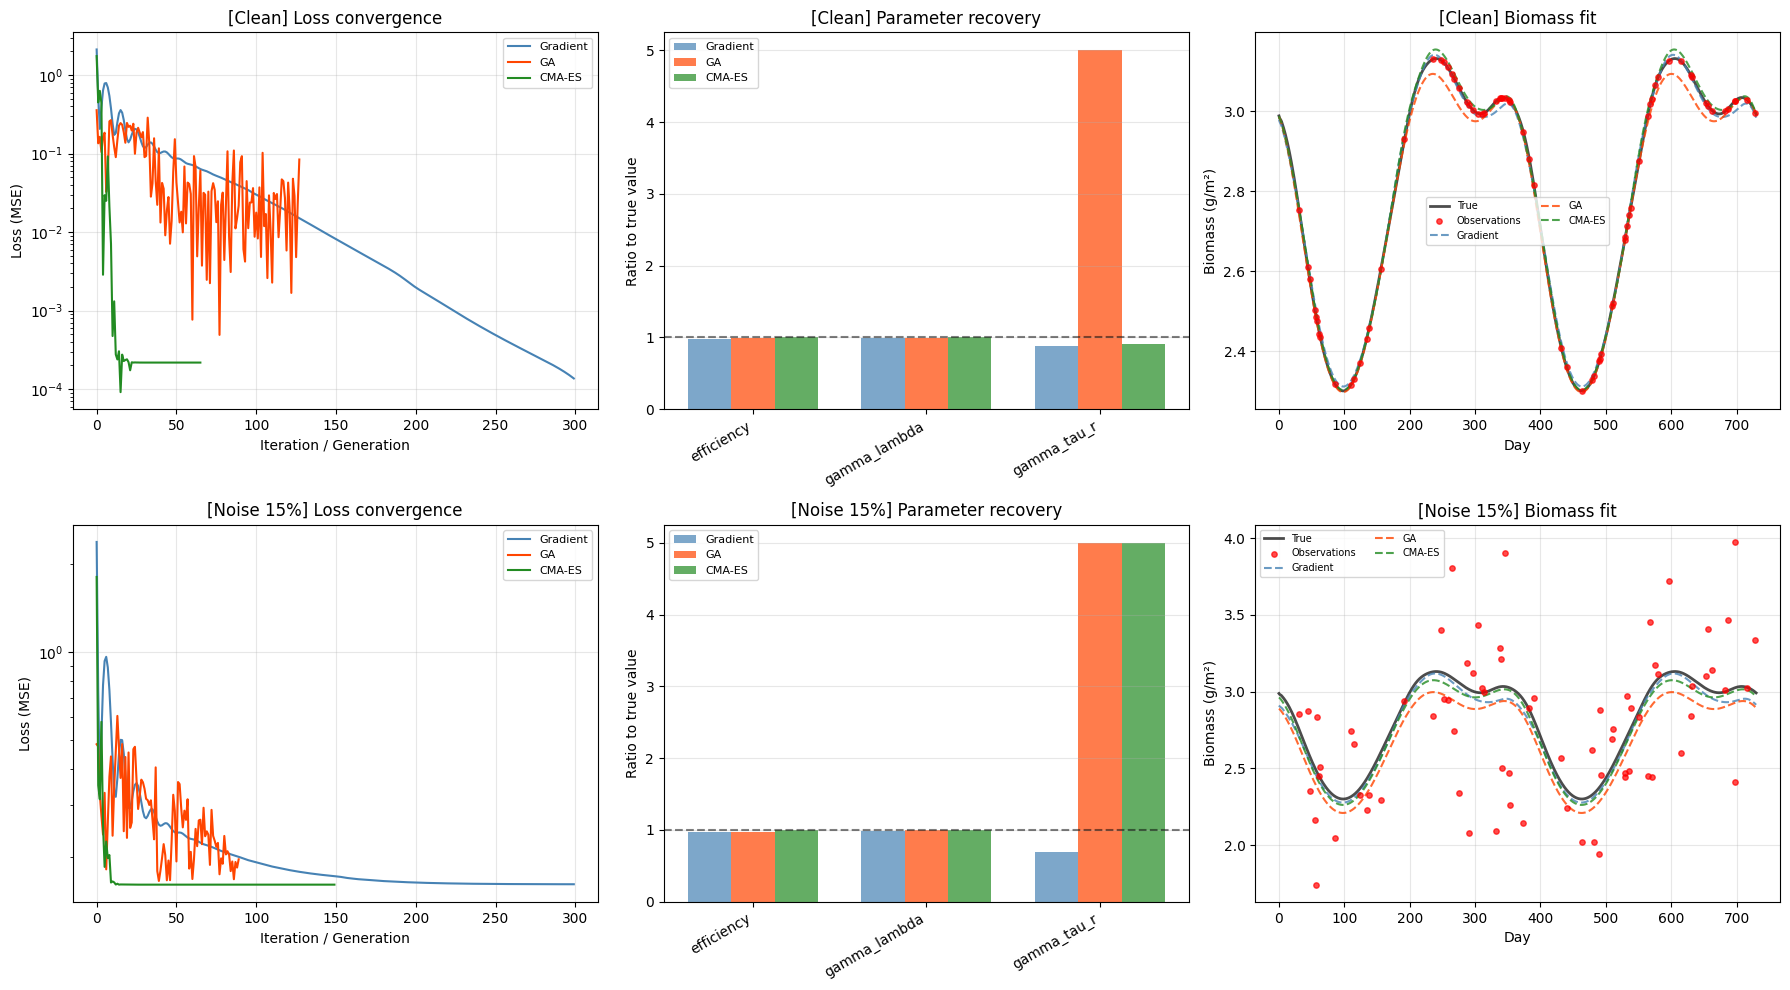

In [9]:
COLORS = {"Gradient": "steelblue", "GA": "orangered", "CMA-ES": "forestgreen"}
n_noise = len(NOISE_LEVELS)

fig, axes = plt.subplots(n_noise, 3, figsize=(18, 5 * n_noise))
if n_noise == 1:
    axes = axes[np.newaxis, :]

for row, noise_level in enumerate(NOISE_LEVELS):
    noise_label = "Clean" if noise_level == 0.0 else f"Noise {noise_level:.0%}"

    # Prepare noisy observations for scatter
    if noise_level > 0:
        noise_rng = np.random.default_rng(SEED + 1)
        obs_values = obs_clean + noise_rng.normal(0, noise_level * np.abs(obs_clean))
    else:
        obs_values = obs_clean

    # --- Col 0: Loss convergence ---
    ax = axes[row, 0]
    for method in METHODS:
        res = all_results[(noise_level, method)]["result"]
        ax.semilogy(res.loss_history, color=COLORS[method], linewidth=1.5, label=method)
    ax.set_xlabel("Iteration / Generation")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(f"[{noise_label}] Loss convergence")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Col 1: Parameter recovery ---
    ax = axes[row, 1]
    x = np.arange(len(OPT_PARAM_NAMES))
    width = 0.25
    for i, method in enumerate(METHODS):
        res = all_results[(noise_level, method)]["result"]
        ratios = [float(jnp.squeeze(res.params[p])) / TRUE_PARAMS[p] for p in OPT_PARAM_NAMES]
        ax.bar(x + i * width, ratios, width, label=method, color=COLORS[method], alpha=0.7)
    ax.axhline(y=1, color="k", linestyle="--", alpha=0.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels(OPT_PARAM_NAMES, rotation=30, ha="right")
    ax.set_ylabel("Ratio to true value")
    ax.set_title(f"[{noise_label}] Parameter recovery")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

    # --- Col 2: Biomass fit ---
    ax = axes[row, 2]
    ax.plot(time_days, np.array(true_ts), "k-", linewidth=2, label="True", alpha=0.7)
    ax.scatter(
        obs_local_idx * dt_sec / 86400.0,
        obs_values,
        c="red",
        s=15,
        zorder=5,
        label="Observations",
        alpha=0.7,
    )
    for method in METHODS:
        res = all_results[(noise_level, method)]["result"]
        _, out = run(step_fn, model, dict(model.state), {**model.parameters, **res.params})
        bio = out["biomass"]
        ts = jnp.mean(bio, axis=tuple(range(1, bio.ndim)))[spinup_steps:]
        ax.plot(time_days, np.array(ts), "--", color=COLORS[method], linewidth=1.5, label=method, alpha=0.8)
    ax.set_xlabel("Day")
    ax.set_ylabel("Biomass (g/m²)")
    ax.set_title(f"[{noise_label}] Biomass fit")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Summary

|                      | Gradient (Adam)               | GA                        | CMA-ES                   |
| -------------------- | ----------------------------- | ------------------------- | ------------------------ |
| **Type**             | First-order gradient          | Evolutionary              | Evolutionary             |
| **Gradients**        | Yes (`jax.value_and_grad`)    | No                        | No                       |
| **Population**       | —                             | 64                        | 32                       |
| **Convergence**      | Fast (smooth loss)            | Moderate                  | Fast (adapts covariance) |
| **Noise robustness** | Fits noise directly           | Population averages noise | Adapts to noise          |
| **Best for**         | Smooth, differentiable models | Discontinuous landscapes  | Noisy, non-smooth        |

**Key takeaways:**

- **Gradient descent** converges fastest on clean data (exact gradients), but may
  overfit noisy observations since it follows the gradient exactly.
- **GA** explores broadly via crossover and mutation but converges slowly — useful
  when the loss landscape is discontinuous.
- **CMA-ES** adapts its search covariance to the local geometry, combining
  exploration efficiency with fast convergence.
- `gamma_tau_r` is harder to recover for all methods — it has weak sensitivity
  in this model configuration.
